In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score as f1, accuracy_score as acc , precision_score as precision, recall_score as recall, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB as nb
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# this will be useful at the time of inference
targets = iris["target_names"]

In [99]:
def draw_pair_plot(X, y):
    df = pd.DataFrame(X)
    df["target"] = targets[y]
    sns.pairplot(df, hue = "target")

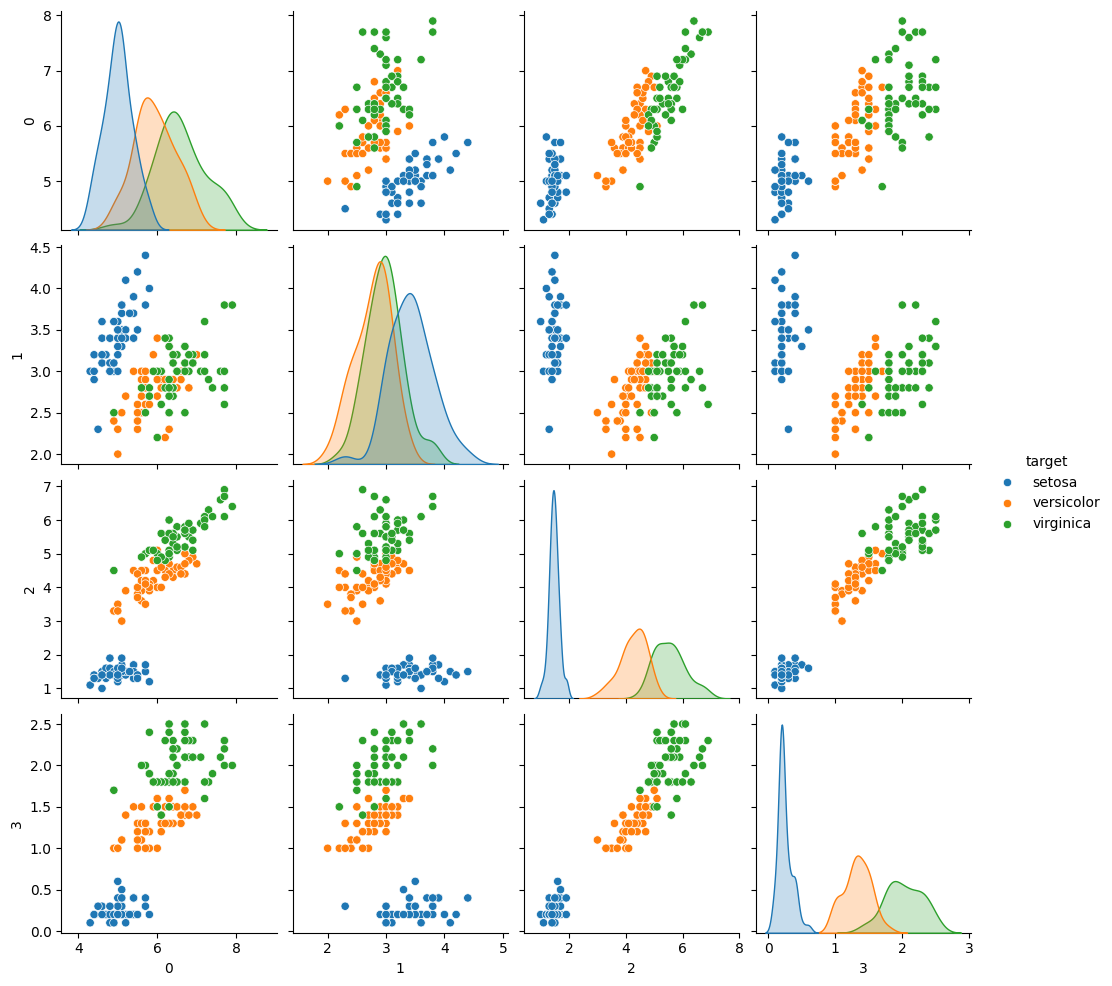

In [100]:
draw_pair_plot(X_iris, y_iris)

In [ ]:
# the sentosa seems skewed but its not actually skewed. It is not centred.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, random_state = 457, test_size = 0.2
);
sc_obj = StandardScaler()
X_train = sc_obj.fit_transform(X_train)
X_test = sc_obj.transform(X_test)

In [36]:
classification_metrics = {
    "accuracy": lambda y_pred, y: acc(y, y_pred),
    "f1_weighted": lambda y_pred, y: f1(y, y_pred, average = "macro")
}

In [37]:
def train_test_models(model = None, metrics = classification_metrics):
    model.fit(X_train, y_train)
    model.predict(X_test)
    metric_list = []
    for metric in metrics:
        metric_list.append(metrics[metric](y_test, model.predict(X_test)))
    return metric_list

[[0.9666666666666667, 0.9665831244778613], [0.9333333333333333, 0.9333333333333332], [0.9, 0.899749373433584], [0.9333333333333333, 0.9333333333333332], [0.9333333333333333, 0.9333333333333332], [0.9333333333333333, 0.9333333333333332]]


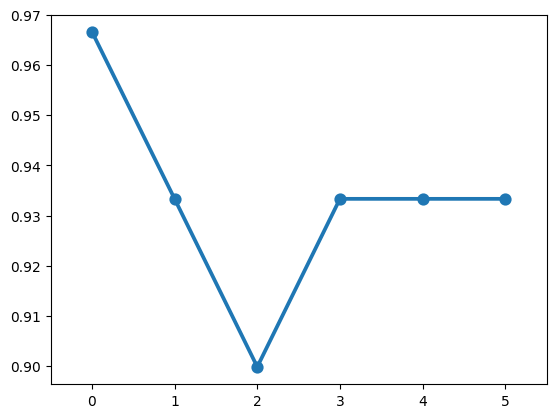

In [94]:
knn_obj = KNN(n_neighbors= 5)
sv_obj = SVC(degree = 2)
nb_obj = nb()
dt_obj = DecisionTreeClassifier(max_depth = 4)
rf_obj = RandomForestClassifier()
xg_obj = XGBClassifier()

classifiers = [knn_obj, sv_obj, nb_obj, dt_obj, rf_obj, xg_obj]
metrics = []
for classifier in classifiers:
    metrics.append(train_test_models(classifier))

classifiers_name = ["knn", "svc", "nb", "dt", "rf", "xg"]
sns.pointplot(metrics)
print(metrics)

## The KNN with neighbours = 5 is best with 96%

In [98]:
import joblib
from google.colab import drive
drive.mount("/content/drive")
knn_obj.fit(X_train, y_train)

joblib.dump(knn_obj, "/content/drive/MyDrive/knn_model.pkl")

Mounted at /content/drive


['/content/drive/MyDrive/knn_model.pkl']

In [106]:
pd.DataFrame(classification_report(y_test, knn_obj.predict(X_test), output_dict= True)).transpose()

,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,10.000000
1,0.909091,1.000000,0.952381,10.000000
2,1.000000,0.900000,0.947368,10.000000
accuracy,0.966667,0.966667,0.966667,0.966667
macro avg,0.969697,0.966667,0.966583,30.000000
weighted avg,0.969697,0.966667,0.966583,30.000000
